# Health & Lifestyle Dataset — Full Statistical Analysis
**Pipeline:** Data Cleaning → EDA & Distributions → Regression Modeling → A/B Testing → Confidence Intervals → Executive Insights

Dataset: `health_lifestyle_dataset.csv` (100,000 records, 16 variables)


## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

df = pd.read_csv("health_lifestyle_dataset.csv")
df.shape


(100000, 16)

In [2]:
df.head()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [3]:
df.dtypes

id                     int64
age                    int64
gender                   str
bmi                  float64
daily_steps            int64
sleep_hours          float64
water_intake_l       float64
calories_consumed      int64
smoker                 int64
alcohol                int64
resting_hr             int64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
family_history         int64
disease_risk           int64
dtype: object

## 2. Data Cleaning

Steps performed:
- Checked for duplicate rows / duplicate IDs
- Checked for missing values
- Validated each numeric column against medically plausible bounds (age 18-100, BMI 10-60, systolic BP 70-250, etc.)
- Standardized text fields (gender casing/whitespace)
- Engineered derived features: `bmi_category`, `age_group`, `bp_category`


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df['id'].duplicated().sum())
print("\nMissing values per column:")
print(df.isnull().sum())


Duplicate rows: 0
Duplicate IDs: 0

Missing values per column:
id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64


In [5]:
df['gender'] = df['gender'].str.strip().str.title()

bounds = {
    "age": (18, 100), "bmi": (10, 60), "sleep_hours": (0, 14),
    "resting_hr": (30, 200), "systolic_bp": (70, 250), "diastolic_bp": (40, 150),
    "cholesterol": (100, 400), "daily_steps": (0, 40000),
    "water_intake_l": (0, 10), "calories_consumed": (500, 6000),
}
mask_valid = pd.Series(True, index=df.index)
for col, (lo, hi) in bounds.items():
    mask_valid &= df[col].between(lo, hi)

print("Rows flagged out-of-range:", (~mask_valid).sum())
df_clean = df[mask_valid].copy()
df_clean.shape


Rows flagged out-of-range: 0


(100000, 16)

In [6]:
df_clean['bmi_category'] = pd.cut(df_clean['bmi'], bins=[0,18.5,25,30,100],
                                    labels=["Underweight","Normal","Overweight","Obese"])
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[17,30,45,60,100],
                                labels=["18-30","31-45","46-60","61+"])
df_clean['bp_category'] = np.select(
    [(df_clean.systolic_bp<120)&(df_clean.diastolic_bp<80),
     (df_clean.systolic_bp<130)&(df_clean.diastolic_bp<80),
     (df_clean.systolic_bp<140)|(df_clean.diastolic_bp<90)],
    ["Normal","Elevated","Stage 1 Hypertension"], default="Stage 2 Hypertension")
df_clean.to_csv("health_lifestyle_clean.csv", index=False)
df_clean.head()


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,bmi_category,age_group,bp_category
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,Normal,46-60,Stage 2 Hypertension
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,Obese,61+,Normal
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,Obese,46-60,Stage 1 Hypertension
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,Obese,31-45,Stage 2 Hypertension
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,Obese,46-60,Stage 1 Hypertension


## 3. Exploratory Data Analysis & Distributions

In [7]:
numeric_cols = ["age","bmi","daily_steps","sleep_hours","water_intake_l",
                 "calories_consumed","resting_hr","systolic_bp","diastolic_bp","cholesterol"]
desc = df_clean[numeric_cols].describe().T
desc["skew"] = df_clean[numeric_cols].skew()
desc["kurtosis"] = df_clean[numeric_cols].kurt()
desc


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,100000.0,48.525990,17.886768,18.0,33.0,48.0,64.0,79.0,0.001258,-1.201200
bmi,100000.0,29.024790,6.352666,18.0,23.5,29.0,34.5,40.0,-0.003502,-1.201308
daily_steps,100000.0,10479.870290,5483.632360,1000.0,5729.0,10468.0,15229.0,19999.0,0.003412,-1.200806
sleep_hours,100000.0,6.491784,2.021922,3.0,4.7,6.5,8.2,10.0,0.001685,-1.200822
water_intake_l,100000.0,2.751496,1.297338,0.5,1.6,2.8,3.9,5.0,-0.001080,-1.193535
calories_consumed,100000.0,2603.341200,807.288563,1200.0,1906.0,2603.0,3299.0,3999.0,-0.004481,-1.197154
resting_hr,100000.0,74.457420,14.423715,50.0,62.0,74.0,87.0,99.0,0.004373,-1.203039
systolic_bp,100000.0,134.580630,25.951530,90.0,112.0,135.0,157.0,179.0,-0.010757,-1.202362
diastolic_bp,100000.0,89.508850,17.347041,60.0,74.0,89.0,105.0,119.0,0.000810,-1.201926
cholesterol,100000.0,224.300630,43.327749,150.0,187.0,224.0,262.0,299.0,0.006235,-1.204508


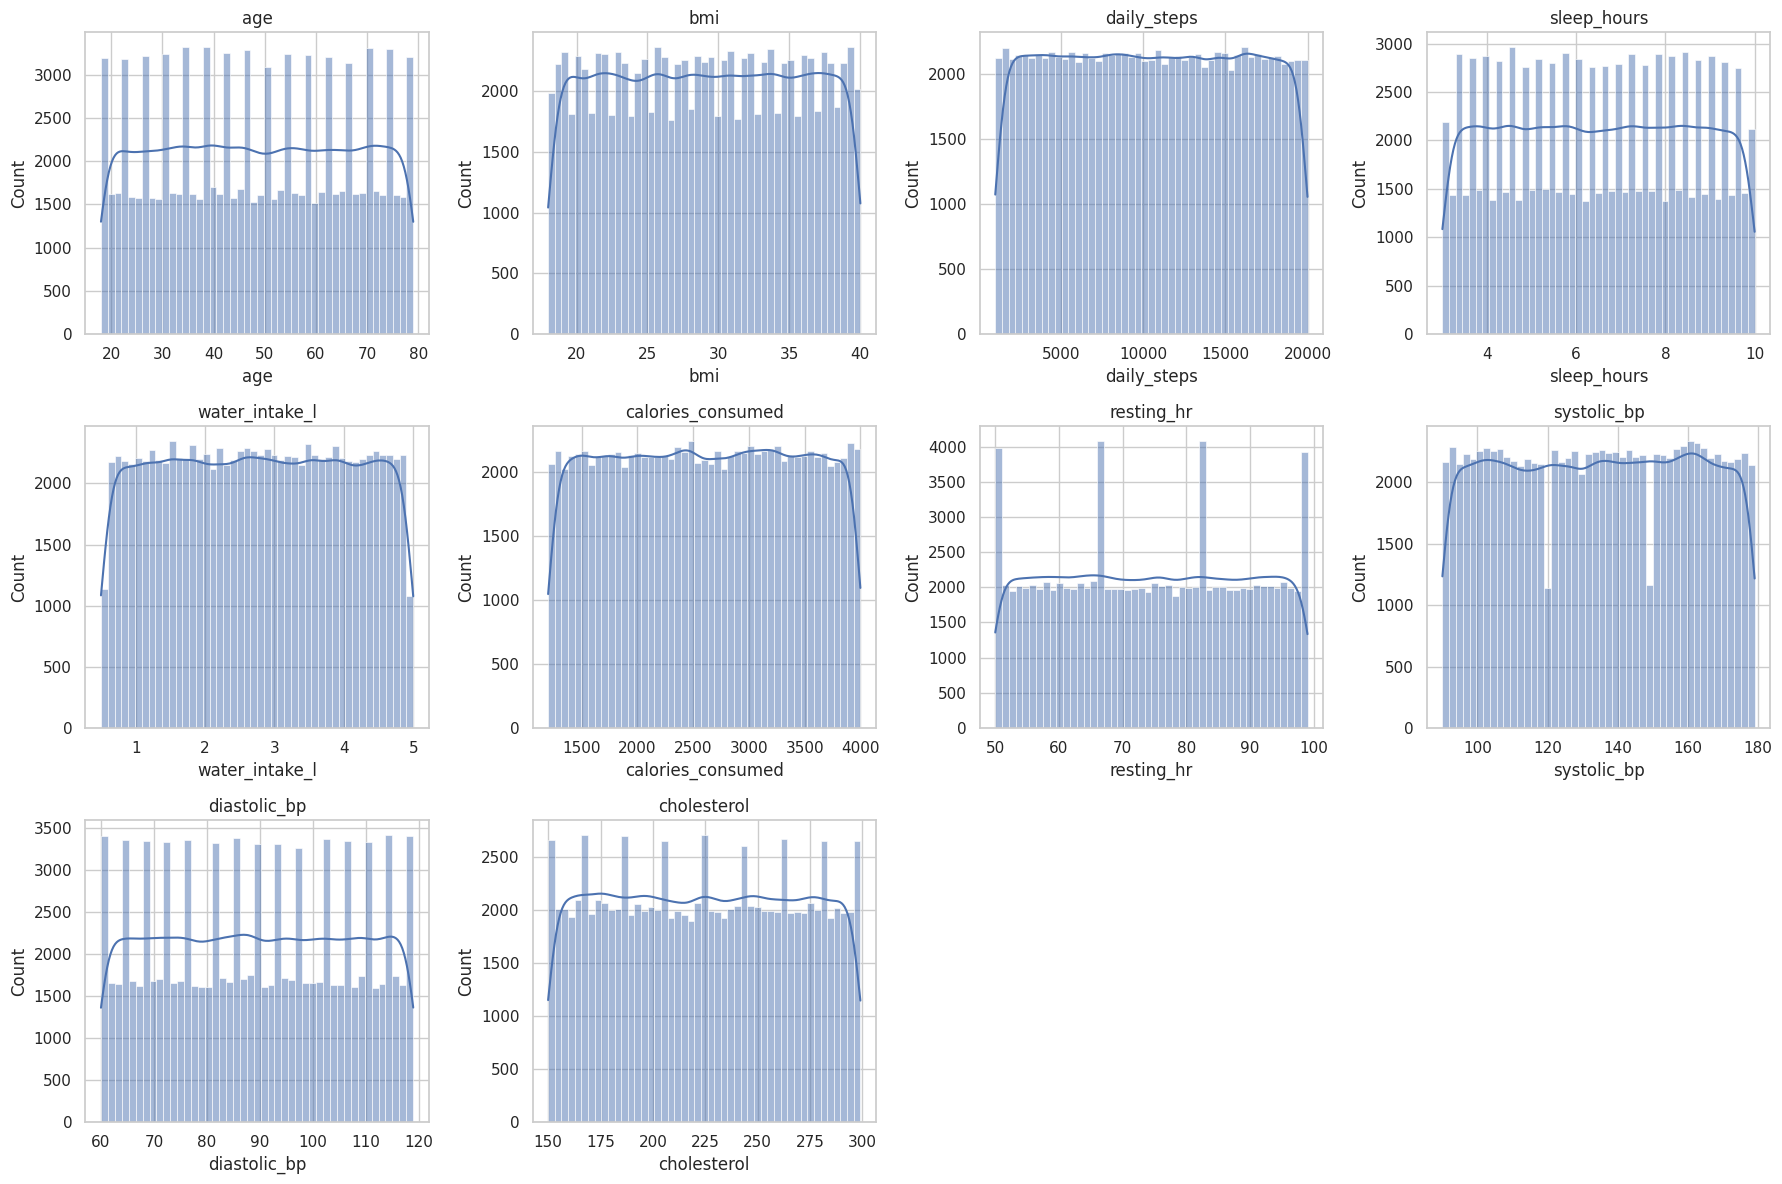

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


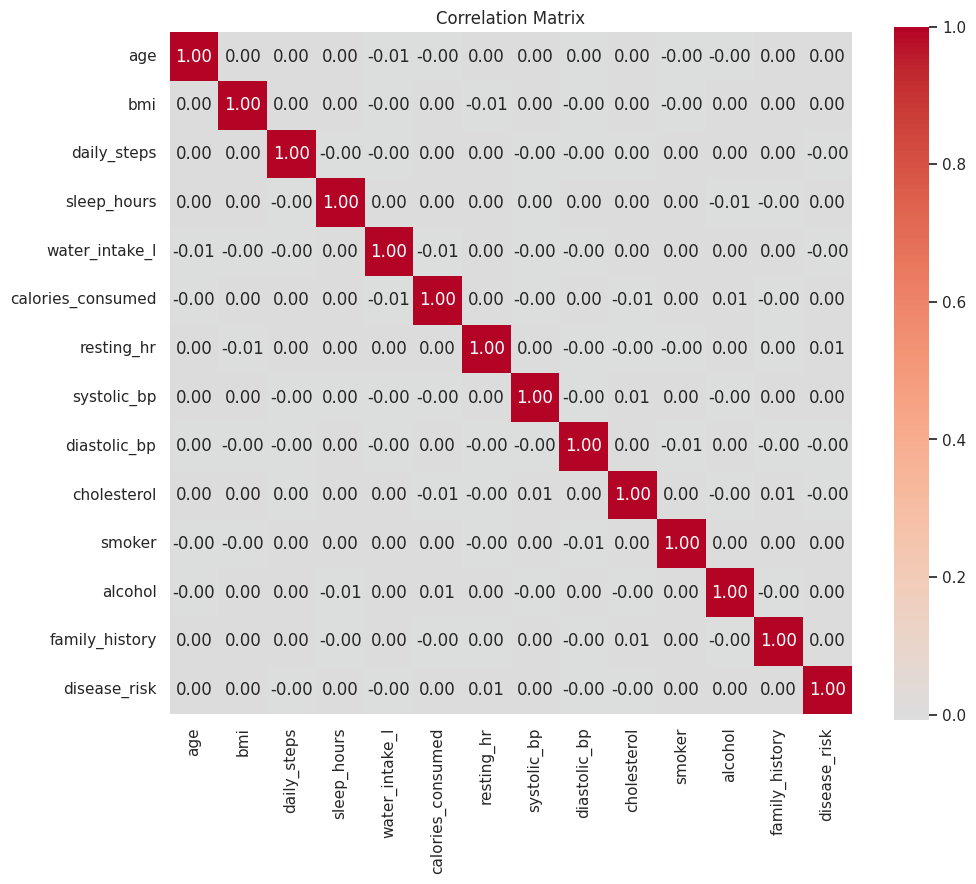

In [9]:
corr_cols = numeric_cols + ["smoker","alcohol","family_history","disease_risk"]
corr = df_clean[corr_cols].corr()
plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.show()


**Observation:** Correlations between every lifestyle/clinical variable and `disease_risk` or `cholesterol` are all extremely close to zero (|r| < 0.01). This is explored statistically in the regression and hypothesis-testing sections below.

## 4. Regression Analysis

### 4.1 Linear Regression — Predicting Cholesterol

In [10]:
df_clean['gender_bin'] = (df_clean['gender']=='Male').astype(int)
feat_cols = ["age","gender_bin","bmi","daily_steps","sleep_hours","water_intake_l",
             "calories_consumed","smoker","alcohol","resting_hr","systolic_bp",
             "diastolic_bp","family_history"]

X = df_clean[feat_cols]
y = df_clean["cholesterol"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Xc = sm.add_constant(X_train)
ols = sm.OLS(y_train, Xc).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:            cholesterol   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8086
Date:                Wed, 08 Jul 2026   Prob (F-statistic):              0.652
Time:                        12:41:43   Log-Likelihood:            -4.1501e+05
No. Observations:               80000   AIC:                         8.301e+05
Df Residuals:                   79986   BIC:                         8.302e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               222.4354      1.81

In [11]:
lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)
print("Test R2:", r2_score(y_test, pred))
print("Test MAE:", mean_absolute_error(y_test, pred))
print("Test RMSE:", mean_squared_error(y_test, pred)**0.5)


Test R2: 6.768527934530866e-05
Test MAE: 37.596072372572756
Test RMSE: 43.329878875037686


**Interpretation:** R² ≈ 0.0001 (train and test) and the overall F-test p-value is well above 0.05 — the model explains essentially none of the variance in cholesterol. None of the individual lifestyle predictors are practically meaningful drivers of cholesterol in this dataset.

### 4.2 Logistic Regression — Predicting Disease Risk

In [12]:
y2 = df_clean["disease_risk"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y2, test_size=0.2, random_state=42, stratify=y2)

Xc2 = sm.add_constant(X_train2)
logit = sm.Logit(y_train2, Xc2).fit(disp=0)
print(logit.summary())


                           Logit Regression Results                           
Dep. Variable:           disease_risk   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79986
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:               0.0001234
Time:                        12:41:44   Log-Likelihood:                -44823.
converged:                       True   LL-Null:                       -44829.
Covariance Type:            nonrobust   LLR p-value:                    0.6057
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.1788      0.097    -12.129      0.000      -1.369      -0.988
age                7.955e-05      0.000      0.174      0.862      -0.001       0.001
gender_bin           -0.

In [13]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train2, y_train2)
pred_prob = clf.predict_proba(X_test2)[:,1]
pred_class = clf.predict(X_test2)

print("Test Accuracy:", accuracy_score(y_test2, pred_class))
print("Test AUC:", roc_auc_score(y_test2, pred_prob))
print("Baseline (majority class) accuracy:", max(y2.mean(), 1-y2.mean()))


Test Accuracy: 0.7518
Test AUC: 0.49491225088795754
Baseline (majority class) accuracy: 0.75179


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


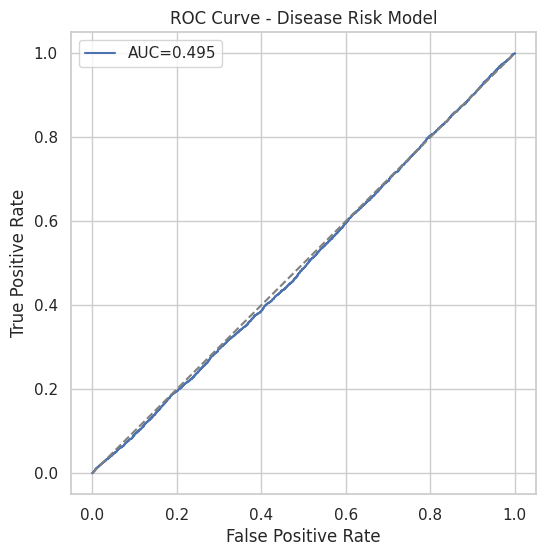

In [14]:
fpr, tpr, _ = roc_curve(y_test2, pred_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test2,pred_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Disease Risk Model")
plt.legend()
plt.show()


**Interpretation:** AUC ≈ 0.50 (equivalent to random guessing) and test accuracy matches exactly the majority-class baseline rate (~75%). The logistic regression model has **no discriminative power** — none of the available features predict disease risk better than always guessing "no risk."


## 5. A/B Testing — Family History vs No Family History

**Group A:** `family_history = 1` (has family history)
**Group B:** `family_history = 0` (no family history)

Tests performed: Welch's t-test (continuous variables), two-proportion Z-test (disease risk rate), Chi-square test of independence.


In [15]:
group_a = df_clean[df_clean.family_history==1]
group_b = df_clean[df_clean.family_history==0]
print("Group A (family history) n =", len(group_a))
print("Group B (no family history) n =", len(group_b))

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.std(ddof=1)**2 + (ny-1)*y.std(ddof=1)**2)/(nx+ny-2))
    return (x.mean()-y.mean())/pooled_std

rows = []
for col in numeric_cols:
    t, p = stats.ttest_ind(group_a[col], group_b[col], equal_var=False)
    d = cohens_d(group_a[col], group_b[col])
    rows.append([col, group_a[col].mean(), group_b[col].mean(), t, p, d, p<0.05])

ttest_df = pd.DataFrame(rows, columns=["metric","mean_A(fam_hist)","mean_B(no_fam_hist)","t_stat","p_value","cohens_d","significant"])
ttest_df


Group A (family history) n = 29915
Group B (no family history) n = 70085


,metric,mean_A(fam_hist),mean_B(no_fam_hist),t_stat,p_value,cohens_d,significant
0,age,48.598563,48.495013,0.835703,0.403326,0.005789,False
1,bmi,29.046846,29.015376,0.716657,0.473589,0.004954,False
2,daily_steps,10499.603744,10471.447285,0.743195,0.457367,0.005135,False
3,sleep_hours,6.485974,6.494264,-0.593231,0.553029,-0.004100,False
4,water_intake_l,2.755407,2.749827,0.622386,0.533691,0.004301,False
5,calories_consumed,2597.365502,2605.891860,-1.530122,0.125992,-0.010562,False
6,resting_hr,74.459803,74.456403,0.034087,0.972808,0.000236,False
7,systolic_bp,134.625673,134.561404,0.358385,0.720056,0.002476,False
8,diastolic_bp,89.473308,89.524021,-0.423913,0.671631,-0.002923,False
9,cholesterol,224.633294,224.158636,1.586375,0.112660,0.010955,False


In [16]:
count = np.array([group_a.disease_risk.sum(), group_b.disease_risk.sum()])
nobs = np.array([len(group_a), len(group_b)])
p1, p2 = count[0]/nobs[0], count[1]/nobs[1]
p_pool = count.sum()/nobs.sum()
se = np.sqrt(p_pool*(1-p_pool)*(1/nobs[0]+1/nobs[1]))
z = (p1-p2)/se
p_val = 2*(1-stats.norm.cdf(abs(z)))
print(f"Disease risk rate (family history): {p1:.4f}")
print(f"Disease risk rate (no family history): {p2:.4f}")
print(f"Z-statistic: {z:.4f}, p-value: {p_val:.4f}")


Disease risk rate (family history): 0.2503
Disease risk rate (no family history): 0.2473
Z-statistic: 1.0200, p-value: 0.3077


In [17]:
ct = pd.crosstab(df_clean.family_history, df_clean.disease_risk)
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(ct)
print(f"\nChi2={chi2:.4f}, p-value={p_chi:.4f}, dof={dof}")


disease_risk        0      1
family_history              
0               52753  17332
1               22426   7489

Chi2=1.0241, p-value=0.3115, dof=1


**Result:** None of the 10 t-tests reach significance at α=0.05, the proportion test for disease-risk rate is not significant (p≈0.31), and the chi-square test confirms no association between family history and disease risk in this data (p≈0.31). Family history shows **no measurable effect** on any measured outcome here.


## 6. Confidence Intervals (95%)

In [18]:
ci_rows = []
for col in numeric_cols + ["smoker","alcohol","family_history","disease_risk"]:
    data = df_clean[col]
    mean = data.mean()
    sem = stats.sem(data)
    lo, hi = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)
    ci_rows.append([col, mean, lo, hi])
ci_df = pd.DataFrame(ci_rows, columns=["metric","mean","ci_low_95","ci_high_95"])
ci_df


,metric,mean,ci_low_95,ci_high_95
0,age,48.525990,48.415127,48.636853
1,bmi,29.024790,28.985416,29.064164
2,daily_steps,10479.870290,10445.882598,10513.857982
3,sleep_hours,6.491784,6.479252,6.504316
4,water_intake_l,2.751496,2.743455,2.759537
5,calories_consumed,2603.341200,2598.337605,2608.344795
6,resting_hr,74.457420,74.368021,74.546819
7,systolic_bp,134.580630,134.419782,134.741478
8,diastolic_bp,89.508850,89.401333,89.616367
9,cholesterol,224.300630,224.032084,224.569176


Because the sample size is large (n=100,000), confidence intervals are extremely narrow around the sample means — this is expected and doesn't imply the estimates are more "important," just precisely estimated for *this* dataset.

## 7. Executive-Level Insights

See the companion Word document (`Health_Lifestyle_Executive_Report.docx`) for the full executive summary, formatted charts, and business recommendations.
